 ### Student name: Kristyan Connolly

 ### Student ID: 25245295

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.decomposition import PCA

from sklearn.preprocessing import RobustScaler

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.svm import SVC


from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.neural_network import MLPClassifier

from sklearn.feature_selection import RFE

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

import pickle

### 1. Data load and Initial EDA

To start I will load the data and extract the target columns and split the data into training and test datasets.

I will then do some intial EDA to help understand the dataset that we are dealing with.

In [7]:
# First lets load the data into a dataframe
df = pd.read_csv('./insurance.csv')


# split the data into features and target
y = df['insurance_cost']
X = df.drop('insurance_cost', axis=1)


# split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)


X_train.head()

,age,gender,bmi,children,smoker,region
332,26,male,33.915,1,no,northwest
355,27,male,32.585,3,no,northeast
138,20,male,28.025,1,yes,northwest
381,28,female,25.800,0,no,southwest
292,25,female,32.230,1,no,southeast


## EDA

In [17]:
train_df = pd.concat([X_train, y_train.rename('insurance_cost')], axis=1)

In [23]:
# Lets see if there are any missing values
train_df.isna().sum()

age               0
gender            0
bmi               0
children          0
smoker            0
region            0
insurance_cost    0
dtype: int64

### Categorical Attributes

In [19]:
# Frequency counts for categorical attributes
categorical_attributes  = train_df.select_dtypes(include=['str']).columns

print("\nCategorical attributes:\n")
print(list(categorical_attributes))

print("\nFrequency counts for categorical attributes:\n")

for column in categorical_attributes: 
    print("\n")
    print(df[column].value_counts(dropna=False))
    print("--------------------------------")


Categorical attributes:

['gender', 'smoker', 'region']

Frequency counts for categorical attributes:



gender
male      676
female    662
Name: count, dtype: int64
--------------------------------


smoker
no     1064
yes     274
Name: count, dtype: int64
--------------------------------


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64
--------------------------------


### Numerical Attributes

In [20]:
# Lets look at the summary statistics for numerical attributes

print("\nSummary statistics for numeric attributes:\n")

train_df.describe()


Summary statistics for numeric attributes:



,age,bmi,children,insurance_cost
count,936.000000,936.000000,936.000000,936.000000
mean,39.099359,30.661608,1.064103,13278.236646
std,14.083242,6.142317,1.186445,12161.071990
min,18.000000,16.815000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4765.098750
50%,39.500000,30.400000,1.000000,9440.087825
75%,51.000000,34.770000,2.000000,16328.508137
max,64.000000,53.130000,5.000000,63770.428010


<Axes: >

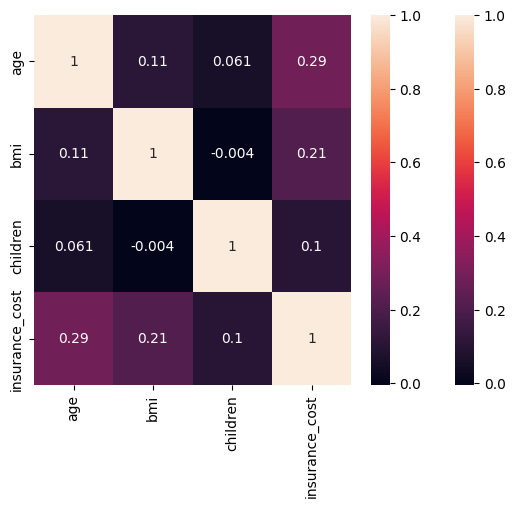

In [22]:
sns.heatmap(train_df.corr(numeric_only=True));

# correlation matrix
corr_matrix = train_df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)


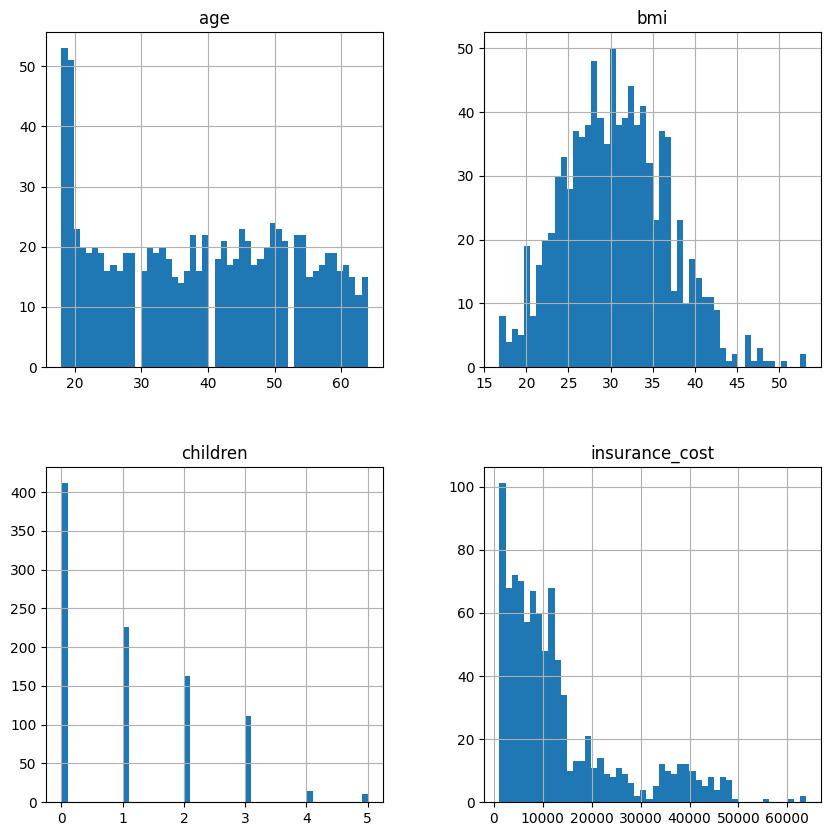

In [24]:
train_df.hist(bins=50, figsize=(10, 10))
plt.show()

<Axes: >

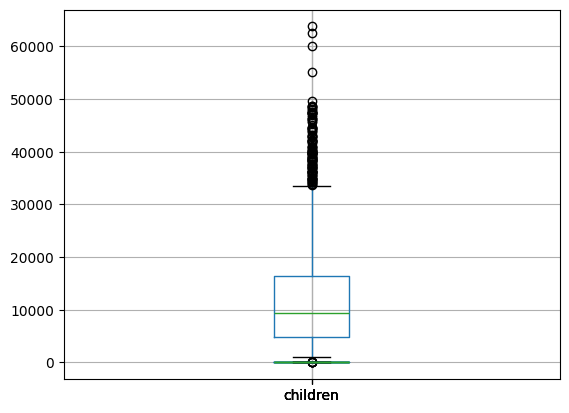

In [ ]:
train_df.boxplot(column='insurance_cost')


<Axes: >

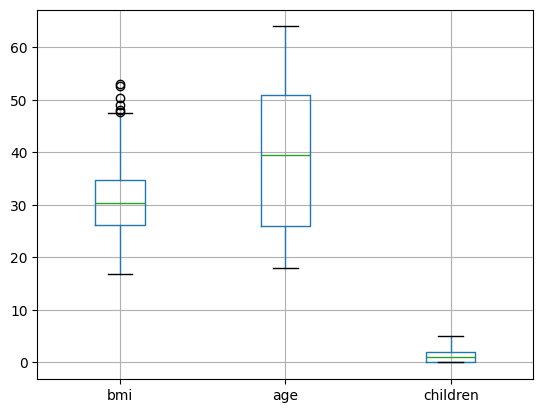

In [33]:
train_df.boxplot(column=['bmi', 'age', 'children'])

### Summary of Inital EDA

The dataset looks quite clean with only a small amount of columns and no missing data.

Observations:
1. bmi is the only column that has any real outliers as seen from the box plots.
2. There is some moderate correlation between age and insurance_cost_binary
3. There is a slight positive correlation between bmi and insurance_cost_binary
4. There are 3 categorical attributes: 'gender', 'smoker' and 'region'
5. age looks uniformly distributed aprt from ages under < 20
6. bmi looks like its normally distributed.
7. children appears to be right skewed.
